Agent-based model for our paper on policy decisions in the context of fast science

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.contrib.concurrent import process_map

class Simulation:
    def __init__(self,
                 fp_cost=-5,
                 fn_cost=-100,
                 minority_type='expert',
                 base_penalty=0.05,        # NEW: How much trust
                                           # is lost on error (0.01 to 0.5)
                 mitigation_factor=1.0,
                 ground_p = .3,
                 leaning_p = .6,
                 polarization_p = .2,
                 leaning_maj_mean_l = .2,
                 leaning_maj_mean_u = .4 # was .4
                 ):
                                           # excuse the error? (0.0 = None, 1.0 = Full)

        self.fp_cost = fp_cost
        self.fn_cost = fn_cost
        self.minority_type = minority_type
        self.base_penalty = base_penalty
        self.mitigation_factor = mitigation_factor
        self.ground_p = ground_p
        self.leaning_p = leaning_p
        self.polarization_p = polarization_p
        self.leaning_maj_mean_l = leaning_maj_mean_l
        self.leaning_maj_mean_u = leaning_maj_mean_u
        self.trust_scores = {'Majority': 1.0, 'Levi': 1.0, 'EU': 1.0, 'Levi_EU': 1.0}     
        self.utilities = {'Majority': 0, 'Levi': 0, 'EU': 0, 'Levi_EU': 1.0}

    def run_round(self):

        # 1. Ground Truth (30% chance of Danger)
        ground_truth = np.random.choice([0, 1], p=[1 - self.ground_p,self.ground_p])

        # self.fn_cost = self.fn_cost * (.5 + np.random.normal(.5, .3, 1))

        # 2. Scenario Generation (Focus on A_leaning/Polarization)
        scenario = np.random.choice(['weak_evidence', 'polarization',
                                     'A_leaning'], p=[1- (self.leaning_p + self.polarization_p),
                                                      self.polarization_p,
                                                      self.leaning_p])

        # 3. Expert Opinion Generation
        n_experts = 5
        experts = []

        def get_dec_maj(eo, threshold):
            return 1 if np.mean(eo) > threshold else 0

        def get_dec_levi(eo, threshold):
            return 1 if np.max(eo) > threshold else 0

        def get_dec_eu(eo):
            mean_exp = np.mean(eo)
            euI = (1-mean_exp) * self.fp_cost + mean_exp * 10    # expected utility intervention
            euNI = mean_exp * self.fn_cost
            return euI > euNI

        def get_dec_levi_eu(eo):
            maxeo = np.max(eo)
            mineo = np.min(eo)
            euImax = (1 - maxeo) * self.fp_cost + maxeo * 10
            euImin = (1 - mineo) * self.fp_cost + mineo * 10
            euNImax = maxeo * self.fn_cost
            euNImin = mineo * self.fn_cost
            return min(euImax,euImin) > min(euNImax, euNImin)
            
        
        if scenario == 'weak_evidence':
            experts = np.random.normal(0.5, 0.15, n_experts)
            eo = np.clip(experts, 0.01, 0.99)

        elif scenario == 'polarization':
            experts = np.concatenate([np.random.normal(0.2, 0.05, 3),
                                      np.random.normal(0.8, 0.05, 2)])
            eo = np.clip(experts, 0.01, 0.99)

        elif scenario == 'A_leaning':
            # majority is conservative
            maj_mean = self.leaning_maj_mean_l if ground_truth == 0 else self.leaning_maj_mean_u
            majority = np.random.normal(maj_mean, 0.1, n_experts - 1)
            majority = np.clip(majority, 0.01, 0.99)

            # minority
            if self.minority_type == 'expert':
                minority_val = np.random.normal(0.85, .1, 1) if ground_truth == 1 else np.random.normal(0.3, .1, 1)
            else: # crank always screams wolf
                minority_val = np.random.normal(0.85, .1, 1)

            experts = np.append(majority, minority_val)
            eo = np.clip(experts, 0.01, 0.99)

        # decisions
        dec_maj = get_dec_maj(eo, .6)
        dec_levi = get_dec_levi(eo, .8)
        dec_eu = get_dec_eu(eo)
        dec_levi_eu = get_dec_levi_eu(eo)

     
        # 5. Calculate Utility for this round
        # Matrix: TP=+10, TN=0, FP=fp_cost, FN=fn_cost
        def get_util(dec, truth):
            if dec == 1 and truth == 1: return 10
            if dec == 0 and truth == 0: return 0
            if dec == 1 and truth == 0: return self.fp_cost
            if dec == 0 and truth == 1: return self.fn_cost
            return 0

        self.utilities['Majority'] += get_util(dec_maj, ground_truth)
        self.utilities['Levi'] += get_util(dec_levi, ground_truth)
        self.utilities['EU'] += get_util(dec_eu, ground_truth)
        self.utilities['Levi_EU'] += get_util(dec_levi_eu, ground_truth)

        # 6. Update Trust
        def update_t(policy, dec):
            current = self.trust_scores[policy]
            if dec == ground_truth:
                return min(1.0, current + 0.01) # Slow recovery
            else:
                # Calculate Penalty
                penalty = self.base_penalty

                # Mitigation Logic
                # Levi communicates the spread.
                if policy == 'Levi' or policy == 'Levi_EU' or policy == 'EU':
                    spread = np.max(eo) - np.min(eo)
                    # If factor is 1.0, high spread eliminates penalty.
                    # If factor is 0.0, spread is ignored (Outcome Bias).
                    penalty = penalty * (1 - (spread * self.mitigation_factor))

                return max(0.0, current - penalty)

        self.trust_scores['Majority'] = update_t('Majority', dec_maj)
        self.trust_scores['Levi'] = update_t('Levi', dec_levi)
        self.trust_scores['EU'] = update_t('EU', dec_eu)
        self.trust_scores['Levi_EU'] = update_t('Levi_EU', dec_levi_eu)

Test suite 1:
- tipping point - costs

In [10]:
def run_test_suite(parameter_name, parameter_values, ground_truth_prob,
                   leaning_prob, polarization_prob, fpcost, n_runs=400):
    results = []

    print(f"Running sweep for {parameter_name}...")

    for val in parameter_values:
        levi_utils = []
        maj_utils = []
        levi_trusts = []
        maj_trusts = []
        eu_utils = []
        eu_trusts = []
        levi_eu_utils = []
        levi_eu_trusts = []

        for _ in range(n_runs):
            # Dynamic kwargs based on what we are testing
            kwargs = {
                'fp_cost': fpcost,
                'minority_type': 'crank', # Default to Crank to stress-test Levi
                'ground_p': ground_truth_prob,
                'leaning_p': leaning_prob,
                'polarization_p': polarization_prob,
                'leaning_maj_mean_u': .4,
            }

            # Inject the sweep parameter
            if parameter_name == 'Inconvenience Cost':
                kwargs['fp_cost'] = val
            elif parameter_name == 'Minority Accuracy':
                # varying probability that minority is expert vs crank
                is_expert = np.random.rand() < val
                kwargs['minority_type'] = 'expert' if is_expert else 'crank'
            elif parameter_name == 'Majority Accuracy':
                kwargs['leaning_maj_mean_u'] = val

            # Run Sim
            sim = Simulation(**kwargs)
            # Run 50 rounds per sim
            for _ in range(50):
                sim.run_round()

            levi_utils.append(sim.utilities['Levi'])
            maj_utils.append(sim.utilities['Majority'])
            eu_utils.append(sim.utilities['EU'])
            levi_eu_utils.append(sim.utilities['Levi_EU'])
            levi_trusts.append(sim.trust_scores['Levi'])
            maj_trusts.append(sim.trust_scores['Majority'])
            eu_trusts.append(sim.trust_scores['EU'])
            levi_eu_trusts.append(sim.trust_scores['Levi_EU'])

        results.append({
            'Parameter': val,
            'Levi_Util_Mean': np.mean(levi_utils),
            'Maj_Util_Mean': np.mean(maj_utils),
            'EU_Util_Mean': np.mean(eu_utils),
            'Levi_EU_Util_Mean': np.mean(levi_eu_utils),
            'Levi_Trust_Mean': np.mean(levi_trusts),
            'Maj_Trust_Mean': np.mean(maj_trusts),
            'EU_Trust_Mean': np.mean(eu_trusts),
            'Levi_EU_Trust_Mean': np.mean(levi_eu_trusts)
        })

    return pd.DataFrame(results)

In [ ]:

# TEST 1: The Tipping Point of Cost
# We vary the cost of a False Positive from -5 (Masks) to -60 (Lockdown?)
# We keep the minority as 'crank' to see when the false alarms become too
# expensive.

df_cost = run_test_suite('Inconvenience Cost', range(-5, -65, -5), .3, .6, .2, -5)
df_cost2 = run_test_suite('Inconvenience Cost', range(-5, -65, -5), .1, .6, .2, -5)
df_cost3 = run_test_suite('Inconvenience Cost', range(-5, -65, -5), .5, .6, .2, -5)

# --- PLOTTING ---
# Combine dataframes for easier plotting with seaborn
df_cost_combined = pd.DataFrame()

# Process df_cost (P(danger)=0.3)
df_temp = df_cost.copy()
df_temp['P_danger'] = 0.3
df_levi = df_temp[['Parameter', 'Levi_Util_Mean', 'P_danger']].rename(columns={'Levi_Util_Mean': 'Utility_Mean'})
df_levi['Policy'] = 'Levi'
df_maj = df_temp[['Parameter', 'Maj_Util_Mean', 'P_danger']].rename(columns={'Maj_Util_Mean': 'Utility_Mean'})
df_maj['Policy'] = 'Majority'
df_cost_combined = pd.concat([df_cost_combined, df_levi, df_maj])

# Process df_cost2 (P(danger)=0.1)
df_temp = df_cost2.copy()
df_temp['P_danger'] = 0.1
df_levi = df_temp[['Parameter', 'Levi_Util_Mean', 'P_danger']].rename(columns={'Levi_Util_Mean': 'Utility_Mean'})
df_levi['Policy'] = 'Levi'
df_maj = df_temp[['Parameter', 'Maj_Util_Mean', 'P_danger']].rename(columns={'Maj_Util_Mean': 'Utility_Mean'})
df_maj['Policy'] = 'Majority'
df_cost_combined = pd.concat([df_cost_combined, df_levi, df_maj])

# Process df_cost3 (P(danger)=0.4)
df_temp = df_cost3.copy()
df_temp['P_danger'] = 0.4
df_levi = df_temp[['Parameter', 'Levi_Util_Mean', 'P_danger']].rename(columns={'Levi_Util_Mean': 'Utility_Mean'})
df_levi['Policy'] = 'Levi'
df_maj = df_temp[['Parameter', 'Maj_Util_Mean', 'P_danger']].rename(columns={'Maj_Util_Mean': 'Utility_Mean'})
df_maj['Policy'] = 'Majority'
df_cost_combined = pd.concat([df_cost_combined, df_levi, df_maj])

fig, ax = plt.subplots(1, 1, figsize=(10, 7)) # Slightly larger figure for better readability

sns.lineplot(data=df_cost_combined, x='Parameter', y='Utility_Mean',
             hue='P_danger', style='Policy', markers=True, ax=ax,
             palette='viridis') # Using 'viridis' colormap for P_danger

ax.set_title('Tipping Point: Cost of False Positives across P(danger)')
ax.set_xlabel('Cost of Action (when Safe)')
ax.set_ylabel('Total Utility')
ax.invert_xaxis() # moving from -5 to -60
ax.grid(True)
ax.legend(title='Scenario') # Add a title to the legend

plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

In [44]:
simulation_args = [
    ('Inconvenience Cost', range(-5, -65, -5), .3, .4, .2, -5),  # df_cost21
    ('Inconvenience Cost', range(-5, -65, -5), .1, .4, .2, -5),  # df_cost22
    ('Inconvenience Cost', range(-5, -65, -5), .5, .4, .2, -5)   # df_cost23
]

# 2. Define a simple wrapper to unpack the arguments
# Multiprocessing handles "helper functions" better than lambdas
def simulation_wrapper(args):
    return run_test_suite(*args)

if __name__ == '__main__':
    # 3. Run with process_map
    # max_workers=6 sets the number of CPU cores to use
    results = process_map(simulation_wrapper, simulation_args, max_workers=3)

    # 4. Unpack results
    df_cost21, df_cost22, df_cost23 = results

  0%|          | 0/3 [00:00<?, ?it/s]

Running sweep for Inconvenience Cost...Running sweep for Inconvenience Cost...Running sweep for Inconvenience Cost...




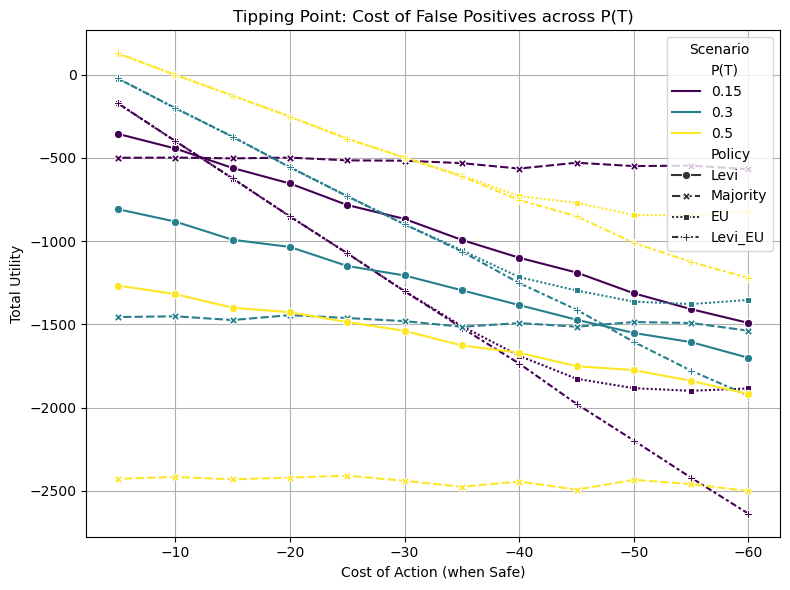

In [51]:
# --- PLOTTING ---
# Combine dataframes for easier plotting with seaborn
df_cost_combined2 = pd.DataFrame()

# Process df_cost (P(danger)=0.3)
df_temp = df_cost21.copy()
df_temp['P(T)'] = 0.3
df_levi = df_temp[['Parameter', 'Levi_Util_Mean', 'P(T)']].rename(columns={'Levi_Util_Mean': 'Utility_Mean'})
df_levi['Policy'] = 'Levi'
df_maj = df_temp[['Parameter', 'Maj_Util_Mean', 'P(T)']].rename(columns={'Maj_Util_Mean': 'Utility_Mean'})
df_maj['Policy'] = 'Majority'
df_eu = df_temp[['Parameter', 'EU_Util_Mean', 'P(T)']].rename(columns={'EU_Util_Mean': 'Utility_Mean'})
df_eu['Policy'] = 'EU'
df_levi_eu = df_temp[['Parameter', 'Levi_EU_Util_Mean', 'P(T)']].rename(columns={'Levi_EU_Util_Mean': 'Utility_Mean'})
df_levi_eu['Policy'] = 'Levi_EU'
df_cost_combined2 = pd.concat([df_cost_combined2, df_levi, df_maj, df_eu, df_levi_eu])

# Process df_cost2 (P(danger)=0.1)
df_temp = df_cost22.copy()
df_temp['P(T)'] = 0.15
df_levi = df_temp[['Parameter', 'Levi_Util_Mean', 'P(T)']].rename(columns={'Levi_Util_Mean': 'Utility_Mean'})
df_levi['Policy'] = 'Levi'
df_maj = df_temp[['Parameter', 'Maj_Util_Mean', 'P(T)']].rename(columns={'Maj_Util_Mean': 'Utility_Mean'})
df_maj['Policy'] = 'Majority'
df_eu = df_temp[['Parameter', 'EU_Util_Mean', 'P(T)']].rename(columns={'EU_Util_Mean': 'Utility_Mean'})
df_eu['Policy'] = 'EU'
df_levi_eu = df_temp[['Parameter', 'Levi_EU_Util_Mean', 'P(T)']].rename(columns={'Levi_EU_Util_Mean': 'Utility_Mean'})
df_levi_eu['Policy'] = 'Levi_EU'
df_cost_combined2 = pd.concat([df_cost_combined2, df_levi, df_maj, df_eu, df_levi_eu])

# Process df_cost3 (P(danger)=0.5)
df_temp = df_cost23.copy()
df_temp['P(T)'] = 0.5
df_levi = df_temp[['Parameter', 'Levi_Util_Mean', 'P(T)']].rename(columns={'Levi_Util_Mean': 'Utility_Mean'})
df_levi['Policy'] = 'Levi'
df_maj = df_temp[['Parameter', 'Maj_Util_Mean', 'P(T)']].rename(columns={'Maj_Util_Mean': 'Utility_Mean'})
df_maj['Policy'] = 'Majority'
df_eu = df_temp[['Parameter', 'EU_Util_Mean', 'P(T)']].rename(columns={'EU_Util_Mean': 'Utility_Mean'})
df_eu['Policy'] = 'EU'
df_levi_eu = df_temp[['Parameter', 'Levi_EU_Util_Mean', 'P(T)']].rename(columns={'Levi_EU_Util_Mean': 'Utility_Mean'})
df_levi_eu['Policy'] = 'Levi_EU'
df_cost_combined2 = pd.concat([df_cost_combined2, df_levi, df_maj, df_eu, df_levi_eu])
fig, ax = plt.subplots(1, 1, figsize=(8, 6)) # Slightly larger figure for better readability

sns.lineplot(data=df_cost_combined2, x='Parameter', y='Utility_Mean',
             hue='P(T)', style='Policy', markers=True, ax=ax,
             palette='viridis') # Using 'viridis' colormap for P_danger

ax.set_title('Tipping Point: Cost of False Positives across P(T)')
ax.set_xlabel('Cost of Action (when Safe)')
ax.set_ylabel('Total Utility')
ax.invert_xaxis() # moving from -5 to -60
ax.grid(True)
ax.legend(title='Scenario') # Add a title to the legend

plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

In [46]:
simulation_args = [
    ('Majority Accuracy', np.linspace(.1, .9, 9), .3, .6, .2, -5), # df_maj1
    ('Majority Accuracy', np.linspace(.1, .9, 9), .3, .6, .2, -30), #df_maj2
    ('Majority Accuracy', np.linspace(.1, .9, 9), .5, .6, .2, -5)  #df_maj3
]

def simulation_wrapper(args):
    return run_test_suite(*args)

if __name__ == '__main__':
    # 3. Run with process_map
    # max_workers=6 sets the number of CPU cores to use
    results = process_map(simulation_wrapper, simulation_args, max_workers=3)

    # 4. Unpack results
    df_maj1, df_maj2, df_maj3 = results

  0%|          | 0/3 [00:00<?, ?it/s]

Running sweep for Majority Accuracy...Running sweep for Majority Accuracy...Running sweep for Majority Accuracy...




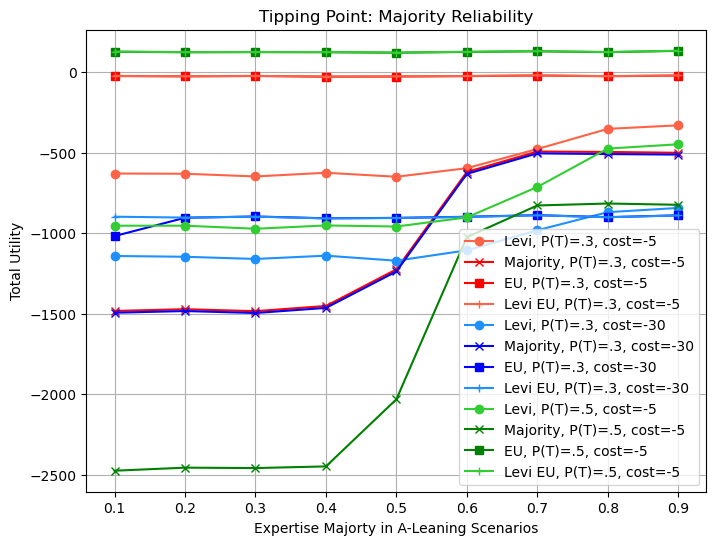

In [47]:
fig, axx = plt.subplots(1, 1, figsize=(8, 6))

axx.plot(df_maj1['Parameter'], df_maj1['Levi_Util_Mean'],
         label='Levi, P(T)=.3, cost=-5', marker='o', color='tomato')
axx.plot(df_maj1['Parameter'], df_maj1['Maj_Util_Mean'],
         label='Majority, P(T)=.3, cost=-5', marker='x', color='red')
axx.plot(df_maj1['Parameter'], df_maj1['EU_Util_Mean'],
         label='EU, P(T)=.3, cost=-5', marker='s', color='red')
axx.plot(df_maj1['Parameter'], df_maj1['Levi_EU_Util_Mean'],
         label='Levi EU, P(T)=.3, cost=-5', marker='+', color='tomato')

axx.plot(df_maj2['Parameter'], df_maj2['Levi_Util_Mean'],
         label='Levi, P(T)=.3, cost=-30', marker='o', color='dodgerblue')
axx.plot(df_maj2['Parameter'], df_maj2['Maj_Util_Mean'],
         label='Majority, P(T)=.3, cost=-30', marker='x', color='blue')
axx.plot(df_maj2['Parameter'], df_maj2['EU_Util_Mean'],
         label='EU, P(T)=.3, cost=-30', marker='s', color='blue')
axx.plot(df_maj2['Parameter'], df_maj2['Levi_EU_Util_Mean'],
         label='Levi EU, P(T)=.3, cost=-30', marker='+', color='dodgerblue')

axx.plot(df_maj3['Parameter'], df_maj3['Levi_Util_Mean'],
         label='Levi, P(T)=.5, cost=-5', marker='o', color='limegreen')
axx.plot(df_maj3['Parameter'], df_maj3['Maj_Util_Mean'],
         label='Majority, P(T)=.5, cost=-5', marker='x', color='green')
axx.plot(df_maj3['Parameter'], df_maj3['EU_Util_Mean'],
         label='EU, P(T)=.5, cost=-5', marker='s', color='green')
axx.plot(df_maj3['Parameter'], df_maj3['Levi_EU_Util_Mean'],
         label='Levi EU, P(T)=.5, cost=-5', marker='+', color='limegreen')

axx.set_title('Tipping Point: Majority Reliability')
axx.set_xlabel('Expertise Majorty in A-Leaning Scenarios')
axx.set_ylabel('Total Utility')
axx.legend()
axx.grid(True)

plt.show()

Test suite 2:
- tipping point - expertise

In [27]:
# TEST 2: The Tipping Point of Expertise
# We vary the probability that the minority is an Expert vs a Crank.
# 0.0 = Always Crank, 1.0 = Always Expert.

simulation_args = [
    ('Minority Accuracy', np.linspace(0, 1, 11), .3, .6, .2, -5),  #df_expert1
    ('Minority Accuracy', np.linspace(0, 1, 11), .15, .6, .2, -5), #df_expert2
    ('Minority Accuracy', np.linspace(0, 1, 11), .5, .6, .2, -5),  #df_expert3
    ('Minority Accuracy', np.linspace(0, 1, 11), .2, .4, .2, -30), #df_exert21
    ('Minority Accuracy', np.linspace(0, 1, 11), .15, .4, .2, -30), #df_expert22
    ('Minority Accuracy', np.linspace(0, 1, 11), .5, .4, .2, -30)   #df_expert23
]

def simulation_wrapper(args):
    return run_test_suite(*args)

if __name__ == '__main__':
    # 3. Run with process_map
    # max_workers=6 sets the number of CPU cores to use
    results = process_map(simulation_wrapper, simulation_args, max_workers=6)

    # 4. Unpack results
    df_expert1, df_expert2, df_expert3, df_expert21, df_expert22, df_expert23 = results

Running sweep for Minority Accuracy...

  0%|          | 0/6 [00:00<?, ?it/s]

Running sweep for Minority Accuracy...Running sweep for Minority Accuracy...Running sweep for Minority Accuracy...Running sweep for Minority Accuracy...Running sweep for Minority Accuracy...







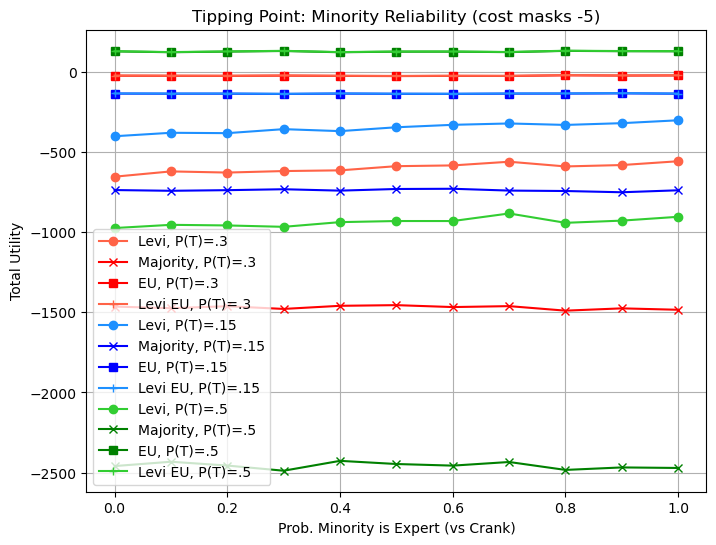

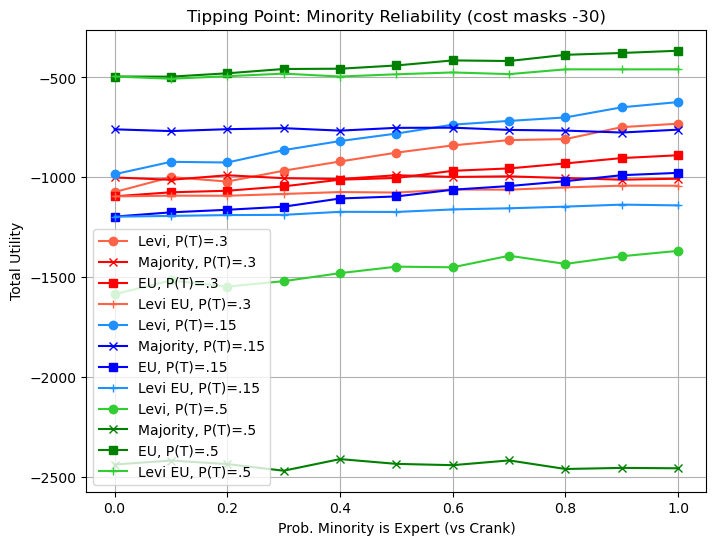

In [35]:
# --- PLOTTING ---
fig, ax2 = plt.subplots(1, 1, figsize=(8, 6))


# Plot 2: Accuracy Sensitivity
ax2.plot(df_expert1['Parameter'], df_expert1['Levi_Util_Mean'],
         label='Levi, P(T)=.3', marker='o', color='tomato')
ax2.plot(df_expert1['Parameter'], df_expert1['Maj_Util_Mean'],
         label='Majority, P(T)=.3', marker='x', color='red')
ax2.plot(df_expert1['Parameter'], df_expert1['EU_Util_Mean'],
         label='EU, P(T)=.3', marker='s', color='red')
ax2.plot(df_expert1['Parameter'], df_expert1['Levi_EU_Util_Mean'],
         label='Levi EU, P(T)=.3', marker='+', color='tomato')

ax2.plot(df_expert2['Parameter'], df_expert2['Levi_Util_Mean'],
         label='Levi, P(T)=.15', marker='o', color='dodgerblue')
ax2.plot(df_expert2['Parameter'], df_expert2['Maj_Util_Mean'],
         label='Majority, P(T)=.15', marker='x', color='blue')
ax2.plot(df_expert2['Parameter'], df_expert2['EU_Util_Mean'],
         label='EU, P(T)=.15', marker='s', color='blue')
ax2.plot(df_expert2['Parameter'], df_expert2['Levi_EU_Util_Mean'],
         label='Levi EU, P(T)=.15', marker='+', color='dodgerblue')

ax2.plot(df_expert3['Parameter'], df_expert3['Levi_Util_Mean'],
         label='Levi, P(T)=.5', marker='o', color='limegreen')
ax2.plot(df_expert3['Parameter'], df_expert3['Maj_Util_Mean'],
         label='Majority, P(T)=.5', marker='x', color='green')
ax2.plot(df_expert3['Parameter'], df_expert3['EU_Util_Mean'],
         label='EU, P(T)=.5', marker='s', color='green')
ax2.plot(df_expert3['Parameter'], df_expert3['Levi_EU_Util_Mean'],
         label='Levi EU, P(T)=.5', marker='+', color='limegreen')

ax2.set_title('Tipping Point: Minority Reliability (cost masks -5)')
ax2.set_xlabel('Prob. Minority is Expert (vs Crank)')
ax2.set_ylabel('Total Utility')
ax2.legend()
ax2.grid(True)

plt.show()

fig, ax22 = plt.subplots(1, 1, figsize=(8, 6))
ax22.plot(df_expert21['Parameter'], df_expert21['Levi_Util_Mean'],
         label='Levi, P(T)=.3', marker='o', color='tomato')
ax22.plot(df_expert21['Parameter'], df_expert21['Maj_Util_Mean'],
         label='Majority, P(T)=.3', marker='x', color='red')
ax22.plot(df_expert21['Parameter'], df_expert21['EU_Util_Mean'],
         label='EU, P(T)=.3', marker='s', color='red')
ax22.plot(df_expert21['Parameter'], df_expert21['Levi_EU_Util_Mean'],
         label='Levi EU, P(T)=.3', marker='+', color='tomato')

ax22.plot(df_expert22['Parameter'], df_expert22['Levi_Util_Mean'],
         label='Levi, P(T)=.15', marker='o', color='dodgerblue')
ax22.plot(df_expert22['Parameter'], df_expert22['Maj_Util_Mean'],
         label='Majority, P(T)=.15', marker='x', color='blue')
ax22.plot(df_expert22['Parameter'], df_expert22['EU_Util_Mean'],
         label='EU, P(T)=.15', marker='s', color='blue')
ax22.plot(df_expert22['Parameter'], df_expert22['Levi_EU_Util_Mean'],
         label='Levi EU, P(T)=.15', marker='+', color='dodgerblue')

ax22.plot(df_expert23['Parameter'], df_expert23['Levi_Util_Mean'],
         label='Levi, P(T)=.5', marker='o', color='limegreen')
ax22.plot(df_expert23['Parameter'], df_expert23['Maj_Util_Mean'],
         label='Majority, P(T)=.5', marker='x', color='green')
ax22.plot(df_expert23['Parameter'], df_expert23['EU_Util_Mean'],
         label='EU, P(T)=.5', marker='s', color='green')
ax22.plot(df_expert23['Parameter'], df_expert23['Levi_EU_Util_Mean'],
         label='Levi EU, P(T)=.5', marker='+', color='limegreen')

ax22.set_title('Tipping Point: Minority Reliability (cost masks -30)')
ax22.set_xlabel('Prob. Minority is Expert (vs Crank)')
ax22.set_ylabel('Total Utility')
ax22.legend()
ax22.grid(True)

plt.show()

Test suite 3
- unforgiving vs forgiving culture

In [18]:
# --- TRUST TEST SUITE ---

def run_trust_sweep(parameter_name, parameter_values, ground_truth_prob, leaning_prob, 
                    polarization_prob, fpcost, leaning_maj_mean_u, n_runs=400):
    results = []
    print(f"Running trust sweep for {parameter_name}...")

    for val in parameter_values:
        levi_trusts = []
        maj_trusts = []
        eu_trusts = []
        levi_eu_trusts = []

        for _ in range(n_runs):
            # Default settings
            kwargs = {
                # Assume worst case (Cranks) to stress test
                'minority_type': 'crank',
                'base_penalty': 0.05,
                'mitigation_factor': 1.0,
                'fp_cost': fpcost,
                'ground_p': ground_truth_prob,
                'leaning_p': leaning_prob,
                'polarization_p': polarization_prob,
                'leaning_maj_mean_u': leaning_maj_mean_u,
            }

            # Inject parameter
            if parameter_name == 'Penalty Severity':
                kwargs['base_penalty'] = val
            elif parameter_name == 'Public Sophistication':
                kwargs['mitigation_factor'] = val

            sim = Simulation(**kwargs)
            for _ in range(50): # 50 Rounds
                sim.run_round()

            levi_trusts.append(sim.trust_scores['Levi'])
            maj_trusts.append(sim.trust_scores['Majority'])
            eu_trusts.append(sim.trust_scores['EU'])
            levi_eu_trusts.append(sim.trust_scores['Levi_EU'])

        results.append({
            'Parameter': val,
            'Levi_Trust_Mean': np.mean(levi_trusts),
            'Maj_Trust_Mean': np.mean(maj_trusts),
            'EU_Trust_Mean': np.mean(eu_trusts),
            'Levi_EU_Trust_Mean': np.mean(levi_eu_trusts)
        })

    return pd.DataFrame(results)


In [36]:
# TEST 3: The "Unforgiving Public"
# Vary penalty from 0.01 (Gentle) to 0.20 (Harsh/Cancel Culture)

simulation_args = [
    ('Penalty Severity', np.linspace(0.01, 0.2, 10), .3, .6, .2, -5, .4),  #df_penalty
    ('Penalty Severity', np.linspace(0.01, 0.2, 10), .15, .6, .2, -5, .4), #df_penalty3
    ('Penalty Severity', np.linspace(0.01, 0.2, 10), .3, .6, .2, -5, .55)  #df_penalty2
]

def simulation_wrapper(args):
    return run_trust_sweep(*args)

if __name__ == '__main__':
    # 3. Run with process_map
    # max_workers=6 sets the number of CPU cores to use
    results = process_map(simulation_wrapper, simulation_args, max_workers=3)

    # 4. Unpack results
    df_penalty, df_penalty3, df_penalty2 = results

  0%|          | 0/3 [00:00<?, ?it/s]

Running trust sweep for Penalty Severity...Running trust sweep for Penalty Severity...Running trust sweep for Penalty Severity...




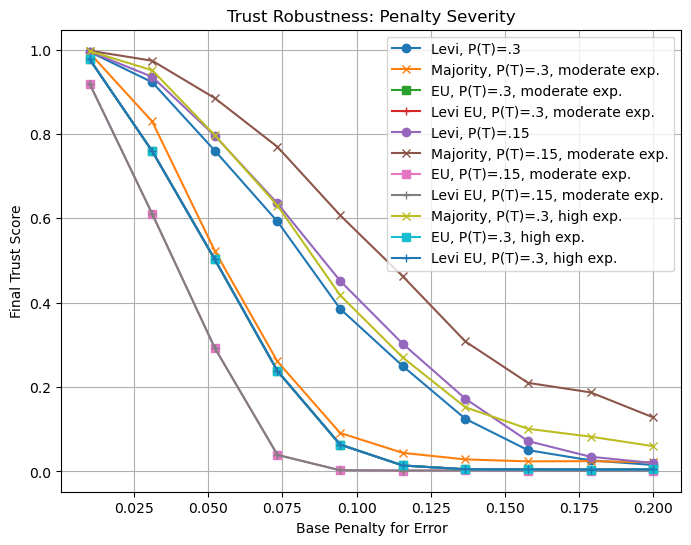

In [37]:
# --- PLOTTING ---
fig, ax3 = plt.subplots(1, 1, figsize=(8, 6))

ax3.plot(df_penalty['Parameter'], df_penalty['Levi_Trust_Mean'],
         label='Levi, P(T)=.3', marker='o')
ax3.plot(df_penalty['Parameter'], df_penalty['Maj_Trust_Mean'],
         label='Majority, P(T)=.3, moderate exp.', marker='x')
ax3.plot(df_penalty['Parameter'], df_penalty['EU_Trust_Mean'],
         label='EU, P(T)=.3, moderate exp.', marker='s')
ax3.plot(df_penalty['Parameter'], df_penalty['Levi_EU_Trust_Mean'],
         label='Levi EU, P(T)=.3, moderate exp.', marker='+')

ax3.plot(df_penalty3['Parameter'], df_penalty3['Levi_Trust_Mean'],
          label='Levi, P(T)=.15', marker='o')
ax3.plot(df_penalty3['Parameter'], df_penalty3['Maj_Trust_Mean'],
         label='Majority, P(T)=.15, moderate exp.', marker='x')
ax3.plot(df_penalty3['Parameter'], df_penalty3['EU_Trust_Mean'],
         label='EU, P(T)=.15, moderate exp.', marker='s')
ax3.plot(df_penalty3['Parameter'], df_penalty3['Levi_EU_Trust_Mean'],
         label='Levi EU, P(T)=.15, moderate exp.', marker='+')

# ax3.plot(df_penalty2['Parameter'], df_penalty2['Levi_Trust_Mean'],
 #        label='Levi Trust, P(threat)=.3', marker='o')
ax3.plot(df_penalty2['Parameter'], df_penalty2['Maj_Trust_Mean'],
         label='Majority, P(T)=.3, high exp.', marker='x')
ax3.plot(df_penalty2['Parameter'], df_penalty2['EU_Trust_Mean'],
         label='EU, P(T)=.3, high exp.', marker='s')
ax3.plot(df_penalty2['Parameter'], df_penalty2['Levi_EU_Trust_Mean'],
         label='Levi EU, P(T)=.3, high exp.', marker='+')


ax3.set_title('Trust Robustness: Penalty Severity')
ax3.set_xlabel('Base Penalty for Error')
ax3.set_ylabel('Final Trust Score')
ax3.legend()
ax3.grid(True)

plt.show()

Test Suite 4:
- outcome bias vs process trust

In [48]:
# TEST 4: The "Outcome Bias" vs "Process Trust"
# Vary mitigation from 0.0 (Pure Outcome Bias) to 1.0 (Understanding/Nuanced)
# 0.0 means: "I don't care that you were unsure, you were wrong."
# 1.0 means: "I forgive you because you told me it was uncertain."
simulation_args = [
    ('Public Sophistication', np.linspace(0, 1, 11), .3, .6, .2, -5, .4),  #df_sophistication
    ('Public Sophistication', np.linspace(0, 1, 11), .4, .6, .2, -5, .4), #df_sophistication2
    ('Public Sophistication', np.linspace(0, 1, 11), .4, .6, .2, -5, .6), #df_sophistication3
    ('Public Sophistication', np.linspace(0, 1, 11), .15, .6, .2, -5, .4) #df_sophistication4
]

def simulation_wrapper(args):
    return run_trust_sweep(*args)

if __name__ == '__main__':
    results = process_map(simulation_wrapper, simulation_args, max_workers=4)
    df_sophistication, df_sophistication2, df_sophistication3, df_sophistication4 = results

  0%|          | 0/4 [00:00<?, ?it/s]

Running trust sweep for Public Sophistication...Running trust sweep for Public Sophistication...Running trust sweep for Public Sophistication...Running trust sweep for Public Sophistication...





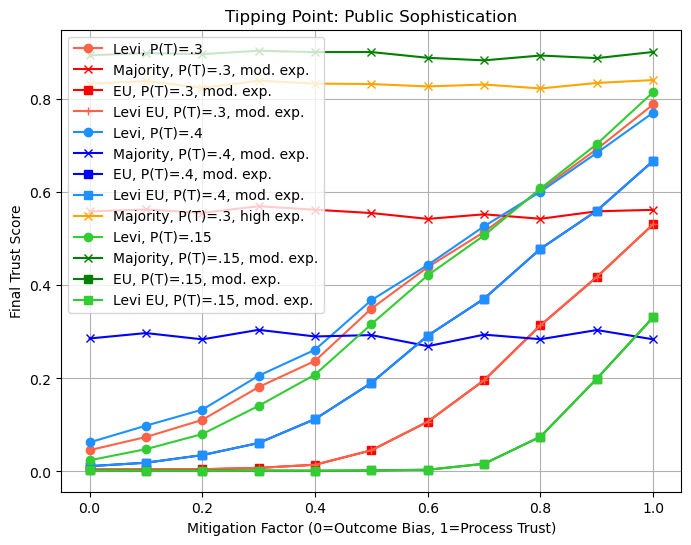

In [49]:
fig, ax4 = plt.subplots(1, 1, figsize=(8, 6))

ax4.plot(df_sophistication['Parameter'], df_sophistication['Levi_Trust_Mean'], 
         label='Levi, P(T)=.3', marker='o', color='tomato')
ax4.plot(df_sophistication['Parameter'], df_sophistication['Maj_Trust_Mean'], 
         label='Majority, P(T)=.3, mod. exp.', marker='x', color='red')
ax4.plot(df_sophistication['Parameter'], df_sophistication['EU_Trust_Mean'], 
         label='EU, P(T)=.3, mod. exp.', marker='s', color='red')
ax4.plot(df_sophistication['Parameter'], df_sophistication['Levi_EU_Trust_Mean'], 
         label='Levi EU, P(T)=.3, mod. exp.', marker='+', color='tomato')

ax4.plot(df_sophistication2['Parameter'], df_sophistication2['Levi_Trust_Mean'], 
          label='Levi, P(T)=.4', marker='o', color='dodgerblue')
ax4.plot(df_sophistication2['Parameter'], df_sophistication2['Maj_Trust_Mean'], 
          label='Majority, P(T)=.4, mod. exp.', marker='x', color='blue')
ax4.plot(df_sophistication2['Parameter'], df_sophistication2['EU_Trust_Mean'], 
          label='EU, P(T)=.4, mod. exp.', marker='s', color='blue')
ax4.plot(df_sophistication2['Parameter'], df_sophistication2['Levi_EU_Trust_Mean'], 
          label='Levi EU, P(T)=.4, mod. exp.', marker='s', color='dodgerblue')

# ax4.plot(df_sophistication3['Parameter'], df_sophistication3['Levi_Trust_Mean'], 
#          label='Levi Trust, P(threat)=.3', marker='o')

ax4.plot(df_sophistication3['Parameter'], df_sophistication3['Maj_Trust_Mean'], 
         label='Majority, P(T)=.3, high exp.', marker='x', color='orange')

ax4.plot(df_sophistication4['Parameter'], df_sophistication4['Levi_Trust_Mean'], 
         label='Levi, P(T)=.15', marker='o', color='limegreen')
ax4.plot(df_sophistication4['Parameter'], df_sophistication4['Maj_Trust_Mean'], 
         label='Majority, P(T)=.15, mod. exp.', marker='x', color='green')
ax4.plot(df_sophistication4['Parameter'], df_sophistication4['EU_Trust_Mean'], 
         label='EU, P(T)=.15, mod. exp.', marker='s', color='green')
ax4.plot(df_sophistication4['Parameter'], df_sophistication4['Levi_EU_Trust_Mean'], 
         label='Levi EU, P(T)=.15, mod. exp.', marker='s', color='limegreen')

ax4.set_title('Tipping Point: Public Sophistication')
ax4.set_xlabel('Mitigation Factor (0=Outcome Bias, 1=Process Trust)')
ax4.set_ylabel('Final Trust Score')
ax4.legend()
ax4.grid(True)

plt.show()